# Phase 5 — 20 Questions

`plan_benzon.md` Part 5 / `plan_benzon_implementation.md` Phase 5 — the one piece that needs
genuinely new infrastructure, not just a new dataset/sentiment pair: the two-phase protocol
(`pipeline.py`) has no notion of multi-turn state, so this phase adds a new module,
`vconf/twenty_questions.py`.

**Played as an actual 20-questions game, not a hinted one.** An earlier version of this
notebook re-stated the harness's own internal "remaining keywords" set to the model on every
single turn (`plan_benzon.md`'s own literal spec, `twenty_questions.NEXT_QUESTION_PROMPT`) —
which meant the model was never really playing the game it was being scored on: it was handed
the answer to "what have I narrowed down so far" instead of having to track it itself. This
notebook now plays the realistic version instead
(`twenty_questions.build_conversation_for_next_question`): each game's 100-keyword universe is
shown exactly **once**, in the very first message, together with the game's rules
(`twenty_questions.GAME_RULES_TEMPLATE`) — including an explicit binary-search strategy
("try to ask a question that eliminates roughly half of whatever keywords are still
possible"), spelled out rather than left for the model to discover, since the whole point of
the `impurity` self-report below is to judge how well it actually follows that strategy. Every
later question-generation call replays the model's own prior questions and the harness's
truthful "Yes"/"No" replies to them as a real, growing chat history — the model has to
remember and reason about what it's already asked, the same way an actual player would, rather
than being told directly. The harness still tracks the true candidate pool internally (needed
to compute `metrics.gini_impurity` and to answer truthfully), but that bookkeeping is never
shown to the model.

**Two model calls per turn:**

1. **Generate the question** — from the real conversation so far
   (`build_conversation_for_next_question`), no hints beyond what the model itself has already
   asked and been told.
2. **Partition the remaining keywords** — the expensive new step, and the one place the
   harness's internal candidate pool is actually used: `twenty_questions.build_partition_prompt`
   asks, in one batched call, which of the *harness's own* remaining keywords the
   just-generated question would answer "Yes" to; `parse_partition` reads back the
   `(yes_set, no_set)` split. This is purely bookkeeping for scoring — its result determines
   the truthful "Yes"/"No" reply fed back into the model's own conversation, and separately
   feeds `metrics.gini_impurity`, but the partition itself is never shown to the model.
   `plan_benzon.md`'s own fallback (one call per keyword instead of one batched call) is
   included below too, ready to switch to if the validation gate finds the batched parse
   unreliable — but per the plan's own default, this notebook goes with batched first.

**A self-report + intrinsic ground truth pair, same pattern as Parts 1/4 — but a genuinely
separate call, not a continuation of the game conversation itself**, since merging the two
would mean giving up `pipeline.run_phase1`'s generic single-question/single-answer contract
(the same function every other phase reuses unmodified). Instead, the self-report call is kept
separate but given the *same context* the model had while playing: `trial.question` is built
from `twenty_questions.transcript_summary`, which now restates the full `GAME_RULES_TEMPLATE`
(that game's own keyword list, phrasing rule, and binary-search strategy — identical to that
game's own first message) plus the model's own prior Q&A pairs, rather than a stripped-down
keyword-count-only summary. The self-report question itself is also phrased as a direct
question rather than a bare classification instruction — `sentiment.IMPURITY.lead_in`
overrides the generic "Classify your impurity into one of the following classes..." opening
with "How evenly do you think your question above has split the remaining keywords into two
groups? Choose one of the following classes...". Ground truth for the *actual* answer is the
real Gini impurity (`metrics.gini_impurity`) of the partition step's real
`(yes_set, no_set)` split.

**Categorized keyword universes.** Every game's keyword universe is also restricted to one of
ten WordNet noun categories (`twenty_questions.CATEGORIES`) — still sampled by natural
Brown-corpus frequency and without replacement (`sample_natural_keywords(..., category=...)`),
just from that one semantic slice of the vocabulary rather than the full, unrestricted noun
vocabulary. 7 are concrete, physical-referent categories (animals, plants, food, body parts,
vehicles, structures, containers) and 3 are abstract, no-physical-referent categories
(emotions, cognition, attributes) — `twenty_questions.ABSTRACT_CATEGORIES` names the latter,
so the gate below can report a concrete-vs-abstract rho split alongside the aggregate one, not
just one pooled number. 10 categories × 10 independently-sampled games per category gives 100
games total.

**Cost note** (`plan_benzon.md`'s own): two model calls per turn × `N_TURNS` turns × 100 games
is real, billable compute — 100 independently-sampled, category-restricted 100-word keyword
universes, exactly 10 turns each (no early stop), **1000 self-report trials total**. A
100-keyword universe needs at least ⌈log₂ 100⌉ = 7 turns of maximally-informative (perfectly
even) splits to isolate one secret, so `N_TURNS` is set above that floor, precisely so a game
actually has room to make real progress turn over turn instead of hitting the cap before it's
said anything.

**Validation gate first** (`plan_benzon_implementation.md`'s explicit go/no-go step, before
building anything else on top of it): the partition-grading call is run on a handful of real
generated questions and its parse printed for inspection *before* any full game is played.

In [1]:
import json
import os
import pathlib
import random
import sys
from dataclasses import replace

import numpy as np
import pandas as pd

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "vconf").is_dir())
sys.path.insert(0, str(ROOT))

HERE = pathlib.Path.cwd()
with open(HERE / "config.json") as f:
    MODEL_CONFIG = json.load(f)
MODEL_NAME = MODEL_CONFIG["model"]
os.environ["VCONF_MODEL"] = MODEL_NAME
CACHE_DIR = HERE / "cache" / MODEL_NAME
OUT_DIR = HERE / "out" / MODEL_NAME
FIGS_DIR = OUT_DIR / "figs"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR.mkdir(parents=True, exist_ok=True)
TRIAL_LOG_PATH = CACHE_DIR / "trial.json"
CONSTRUCT_PATH = CACHE_DIR / "construct.json"
SCALE = MODEL_CONFIG.get("scale", {})

from vconf import notebook as nb

_run_config = nb.run_config


def _run_config_with_overrides(base="gemma-categorical", **overrides):
    cfg = _run_config(base, **overrides)
    if MODEL_CONFIG.get("attn_implementation"):
        cfg = cfg.scaled(attn_implementation=MODEL_CONFIG["attn_implementation"])
    return cfg


nb.run_config = _run_config_with_overrides
from vconf import metrics as M
from vconf import pipeline
from vconf.sentiment import IMPURITY
from vconf.twenty_questions import (
    ABSTRACT_CATEGORIES,
    CATEGORIES,
    build_conversation_for_next_question,
    build_partition_prompt,
    format_keywords,
    parse_partition,
    sample_natural_keywords,
    transcript_summary,
)

cfg = nb.run_config("gemma-categorical", dataset="twenty-questions", name="twenty-questions")
print(nb.describe(cfg))

profile          : reduced
model            : Qwen/Qwen2.5-7B-Instruct (28 layers)
sentiment        : confidence  (ground truth: correctness)
prompt / dataset : categorical / twenty-questions
layer sweep      : (0, 5, 11, 16, 22, 27)
trial counts     : {'steering': 24, 'patching': 24, 'noising': 32, 'swap': 24, 'attention': 24}
activation set   : 300   calibration set: 40
chat template    : True   attention impl: None
NOTE             : reduced profile — procedures, prompts, positions and
                   metrics follow the manual exactly, but the model and the
                   sample sizes are smaller than the paper's, so the numbers
                   here are not expected to match its reported values.


## Keyword universe

Each game below samples its *own* independent keyword universe — `sample_natural_keywords`
(`vconf/twenty_questions.py`) draws 100 unique English common nouns from the Brown corpus,
weighted by their natural occurrence frequency in written English, not shared across games.
This is not the ``n`` most frequent words (raw frequency in unrestricted text is dominated by
function words: "the", "of", "and", ...) and not a hand-picked category list either (an
earlier version of this notebook used one curated 100-animal set, shared by every session).
Sampling is restricted to common-noun tokens (Brown tags `NN`/`NNS`) and without replacement,
so each universe spans wildly different registers and concreteness — common everyday nouns
sitting next to rare technical terms encountered in only a single genre.

The cell below draws one example universe (`KEYWORDS`, seed 0, uncategorized) purely to
sanity-check the batched partition-grading call in the validation gate further down; it is
*not* reused as the shared universe for the played games later. Each played game instead draws
its own universe *and* restricts it to one of ten WordNet categories
(`twenty_questions.CATEGORIES`, passed as `sample_natural_keywords(..., category=...)`) — see
"Playing sessions" below.

In [2]:
KEYWORDS = sample_natural_keywords(n=100, seed=0)
assert len(set(KEYWORDS)) == len(KEYWORDS) == 100
print(f"{len(KEYWORDS)} keywords: {format_keywords(KEYWORDS)}")

100 keywords: action, activities, afternoon, airdrops, amount, attractions, avenues, baking, bargaining, base, beneficiaries, boos, bronchioles, cafe, card, character, clamor, classes, coal, combustion, commodities, conclusion, conscience, conversation, cost, country, couple, course, creativeness, dealer, development, dictionary, dioxalate, dress, dynamics, effect, eloquence, emotion, end, families, feet, fervors, future, girl, hair, hall, hand, hill, horse, kitchen, lectures, leg, lifeboat, liquor, losers, man, medicine, ministries, moment, needle, officer, opponent, orders, pajamas, parents, partner, past, pathology, people, place, politics, program, projects, questions, realtors, recordings, records, ribbons, runners, safety, scrubbing, sea, security, sentence, sewage, shame, sheriffs, shift, side, sink, slip, sophisticate, theaters, things, time, tin, transom, triphenylarsine, war, woman


In [3]:
loaded = nb.open_model(cfg, device_map=MODEL_CONFIG.get("device_map"))

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

## Generation helpers

Both calls bypass `run_phase0`/`build_phase0_prompt` on purpose, same reasoning as Phase 4's
`generate_list`: neither the question-generation call nor the partition-grading call wants a
confidence-instruction block baked into its prompt, and neither needs position tracking (Phase
5 runs no causal intervention), so both go through one plain chat-templated generation call.
`generate_text` accepts either a single prompt string (wrapped as one user turn — used for the
partition-grading call, which has no multi-turn structure of its own) or an already-built list
of chat messages (used for question generation, where `build_conversation_for_next_question`
supplies the real multi-turn history).

In [4]:
def generate_text(loaded, cfg, prompt, max_new_tokens):
    messages = [{"role": "user", "content": prompt}] if isinstance(prompt, str) else prompt
    if cfg.use_chat_template:
        text = loaded.tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
    else:
        text = messages[-1]["content"]
    enc = loaded.tokenizer(
        [text], return_tensors="pt", add_special_tokens=not cfg.use_chat_template
    ).to(loaded.device)
    out = loaded.model.generate(
        **enc, max_new_tokens=max_new_tokens, do_sample=False, temperature=None, top_p=None,
        top_k=None, repetition_penalty=1.0, pad_token_id=loaded.tokenizer.pad_token_id,
    )
    new_tokens = out[:, enc["input_ids"].shape[1]:]
    return loaded.tokenizer.decode(new_tokens[0], skip_special_tokens=True).strip()


def partition_keywords_per_keyword(loaded, cfg, question, remaining):
    """Fallback for the batched partition call (plan_benzon.md Part 5 step 2's own
    documented fallback) — one Yes/No call per remaining keyword instead of one
    batched call for all of them. Slower (len(remaining) calls instead of 1) but
    immune to a batched-response parse failure; not used below unless the
    validation gate finds the batched parse unreliable."""
    yes, no = [], []
    for kw in remaining:
        prompt = (
            f'Given the question "{question}", would the keyword "{kw}" be answered '
            '"Yes"? Answer with only "Yes" or "No".'
        )
        text = generate_text(loaded, cfg, prompt, max_new_tokens=5)
        (yes if text.strip().lower().startswith("yes") else no).append(kw)
    return tuple(yes), tuple(no)

## Validation gate — is the batched partition parse reliable?

Three real questions, generated against the full keyword universe, each partitioned and
printed in full (raw generation + parsed split) for inspection. The automated check below only
confirms the *structural* invariant (`parse_partition` always produces a clean partition by
construction) — the actual reliability question ("does the YES set make semantic sense for the
question asked?") is a judgment call to make by reading the printed output, per
`plan_benzon_implementation.md`'s own framing of this as a go/no-go step, not a nice-to-have.

In [5]:
for _ in range(3):
    question = generate_text(loaded, cfg, build_conversation_for_next_question(KEYWORDS, []), max_new_tokens=40)
    partition_text = generate_text(loaded, cfg, build_partition_prompt(question, KEYWORDS), max_new_tokens=600)
    yes_set, no_set = parse_partition(partition_text, KEYWORDS)

    assert set(yes_set) | set(no_set) == set(KEYWORDS)
    assert set(yes_set) & set(no_set) == set()

    print(f"question: {question}")
    print(f"raw partition response: {partition_text}")
    print(f"parsed -> YES ({len(yes_set)}): {yes_set}")
    print(f"parsed -> NO  ({len(no_set)}): {no_set}")
    print()

question: Is your keyword a noun related to an activity or action?
raw partition response: **Yes**: action, activities, baking, bargaining, classes, cost, courses, dynamics, future, lectures, past, programs, questions, safety, scrubbing, things, time
parsed -> YES (15): ('action', 'activities', 'baking', 'bargaining', 'classes', 'cost', 'dynamics', 'future', 'lectures', 'past', 'questions', 'safety', 'scrubbing', 'things', 'time')
parsed -> NO  (85): ('afternoon', 'airdrops', 'amount', 'attractions', 'avenues', 'base', 'beneficiaries', 'boos', 'bronchioles', 'cafe', 'card', 'character', 'clamor', 'coal', 'combustion', 'commodities', 'conclusion', 'conscience', 'conversation', 'country', 'couple', 'course', 'creativeness', 'dealer', 'development', 'dictionary', 'dioxalate', 'dress', 'effect', 'eloquence', 'emotion', 'end', 'families', 'feet', 'fervors', 'girl', 'hair', 'hall', 'hand', 'hill', 'horse', 'kitchen', 'leg', 'lifeboat', 'liquor', 'losers', 'man', 'medicine', 'ministries', 'mo

question: Is your keyword a noun related to an activity or action?
raw partition response: **Yes**: action, activities, baking, bargaining, classes, cost, courses, dynamics, future, lectures, past, programs, questions, safety, scrubbing, things, time
parsed -> YES (15): ('action', 'activities', 'baking', 'bargaining', 'classes', 'cost', 'dynamics', 'future', 'lectures', 'past', 'questions', 'safety', 'scrubbing', 'things', 'time')
parsed -> NO  (85): ('afternoon', 'airdrops', 'amount', 'attractions', 'avenues', 'base', 'beneficiaries', 'boos', 'bronchioles', 'cafe', 'card', 'character', 'clamor', 'coal', 'combustion', 'commodities', 'conclusion', 'conscience', 'conversation', 'country', 'couple', 'course', 'creativeness', 'dealer', 'development', 'dictionary', 'dioxalate', 'dress', 'effect', 'eloquence', 'emotion', 'end', 'families', 'feet', 'fervors', 'girl', 'hair', 'hall', 'hand', 'hill', 'horse', 'kitchen', 'leg', 'lifeboat', 'liquor', 'losers', 'man', 'medicine', 'ministries', 'mo

question: Is your keyword a noun related to an activity or action?
raw partition response: **Yes**: action, activities, baking, bargaining, classes, cost, courses, dynamics, future, lectures, past, programs, questions, safety, scrubbing, things, time
parsed -> YES (15): ('action', 'activities', 'baking', 'bargaining', 'classes', 'cost', 'dynamics', 'future', 'lectures', 'past', 'questions', 'safety', 'scrubbing', 'things', 'time')
parsed -> NO  (85): ('afternoon', 'airdrops', 'amount', 'attractions', 'avenues', 'base', 'beneficiaries', 'boos', 'bronchioles', 'cafe', 'card', 'character', 'clamor', 'coal', 'combustion', 'commodities', 'conclusion', 'conscience', 'conversation', 'country', 'couple', 'course', 'creativeness', 'dealer', 'development', 'dictionary', 'dioxalate', 'dress', 'effect', 'eloquence', 'emotion', 'end', 'families', 'feet', 'fervors', 'girl', 'hair', 'hall', 'hand', 'hill', 'horse', 'kitchen', 'leg', 'lifeboat', 'liquor', 'losers', 'man', 'medicine', 'ministries', 'mo

## Playing sessions

10 categories (`twenty_questions.CATEGORIES` — 7 concrete: animals, plants, food, body parts,
vehicles, structures, containers; 3 abstract, `twenty_questions.ABSTRACT_CATEGORIES`: emotions,
cognition, attributes) × 10 games per category = 100 games, each sampling its *own* fresh
100-word keyword universe restricted to that game's category
(`sample_natural_keywords(..., category=...)`, one seed per game) rather than sharing a single
fixed list, or drawing from the unrestricted vocabulary — the secret for a game is drawn from
that game's own universe, never from another game's or another category's. Games are tracked
by a running index (not by secret word), since two independently-sampled universes — even
across different categories — can legitimately draw the same word as their secret; keying by
secret alone would silently collide those. Each turn: the model asks a question from its own
real conversation history (`build_conversation_for_next_question`) — no hint of what's
"remaining"; the harness silently partitions its *own* internal candidate pool (that game's
universe) to determine the truthful "Yes"/"No" reply (and `gini_impurity`), narrows that
internal pool to whichever branch actually contains the secret, and appends `(question,
reply)` to the visible conversation. Every game runs exactly `N_TURNS` turns regardless of
whether it's already effectively isolated the secret or hit an uninformative question — no
early-stop guard, so all 100 games contribute the same number of trials: 10 categories × 10
games × 10 turns = 1000 trials total.

In [6]:
def play_session(loaded, cfg, keywords, secret, n_turns):
    qa_history = []  # exactly what the model has seen: (question, "Yes"/"No") pairs
    remaining = keywords  # harness-internal only — never shown to the model
    records = []
    for i in range(n_turns):
        messages = build_conversation_for_next_question(keywords, qa_history)
        question = generate_text(loaded, cfg, messages, max_new_tokens=40)
        partition_text = generate_text(loaded, cfg, build_partition_prompt(question, remaining), max_new_tokens=600)
        yes_set, no_set = parse_partition(partition_text, remaining)
        answer = "Yes" if secret in yes_set else "No"
        remaining_after = yes_set if secret in yes_set else no_set
        records.append({
            "secret": secret, "turn": i, "qa_history_before": list(qa_history),
            "remaining_before": remaining, "question": question, "answer": answer,
            "yes_set": yes_set, "no_set": no_set, "gini": M.gini_impurity(len(yes_set), len(no_set)),
        })
        qa_history.append((question, answer))
        remaining = remaining_after  # always non-empty: the secret is always in exactly one branch
    return qa_history, records


random.seed(0)
TQ_SCALE = SCALE.get("twenty_questions", {})
N_GAMES_PER_CATEGORY = TQ_SCALE.get("games_per_category", 10)
N_TURNS = TQ_SCALE.get("turns", 10)
UNIVERSE_SIZE = TQ_SCALE.get("universe_size", 100)

# Keyed by a running game index, not secret word: two independently-sampled
# universes — even across different categories — can legitimately draw the
# same word as their secret, so a secret-keyed dict would silently collide
# those.
games = []
for category in CATEGORIES:
    for game_in_category in range(N_GAMES_PER_CATEGORY):
        seed = len(games)  # a fresh, never-reused seed for every game overall
        game_keywords = sample_natural_keywords(n=UNIVERSE_SIZE, seed=seed, category=category)
        secret = random.choice(game_keywords)
        qa_history, records = play_session(loaded, cfg, game_keywords, secret, N_TURNS)
        game_idx = len(games)
        for record in records:
            record["category"] = category
            record["game"] = game_idx
            record["keywords"] = game_keywords
        games.append({
            "category": category, "game": game_idx, "keywords": game_keywords, "secret": secret,
            "qa_history": qa_history, "records": records,
        })

all_records = [record for game in games for record in game["records"]]
assert len(games) == len(CATEGORIES) * N_GAMES_PER_CATEGORY
assert len(all_records) == len(games) * N_TURNS

turns_df = pd.DataFrame(all_records)
turns_df["n_remaining_before"] = turns_df["remaining_before"].apply(len)
turns_df["n_yes"] = turns_df["yes_set"].apply(len)
turns_df["n_no"] = turns_df["no_set"].apply(len)
display(turns_df[["category", "game", "secret", "turn", "question", "answer", "n_remaining_before", "n_yes", "n_no", "gini"]])

,category,game,secret,turn,question,answer,n_remaining_before,n_yes,n_no,gini
0,animal.n.01,0,longhorn,0,Is your keyword a living creature?,Yes,100,62,38,0.471200
1,animal.n.01,0,longhorn,1,Is your keyword an animal?,Yes,62,50,12,0.312175
2,animal.n.01,0,longhorn,2,Is your keyword a mammal?,Yes,50,23,27,0.496800
3,animal.n.01,0,longhorn,3,Is your keyword a domesticated animal?,No,23,9,14,0.476371
4,animal.n.01,0,longhorn,4,Is your keyword a wild animal?,No,14,6,8,0.489796
...,...,...,...,...,...,...,...,...,...,...
995,attribute.n.02,99,cruelty,5,Is your keyword a noun that describes a place ...,No,12,3,9,0.375000
996,attribute.n.02,99,cruelty,6,Is your keyword a noun that describes an abstr...,Yes,9,7,2,0.345679
997,attribute.n.02,99,cruelty,7,Is your keyword a noun that describes a feelin...,Yes,7,3,4,0.489796
998,attribute.n.02,99,cruelty,8,Is your keyword a noun that describes a negati...,Yes,3,3,0,0.000000


## Full chat history of one game

The actual chat-message list (`role`/`content` pairs) for one session, as fed to
`tokenizer.apply_chat_template` — this *is* the model's entire memory of the game: the keyword
list appears once, in the first message, and everything after that is its own real questions
and the harness's true replies.

In [7]:
import json

example_game = games[0]
example_messages = build_conversation_for_next_question(example_game["keywords"], example_game["qa_history"])
print(
    f"game = {example_game['game']}, category = {example_game['category']!r}, "
    f"secret = {example_game['secret']!r}, {len(example_messages)} messages\n"
)
print(json.dumps(example_messages, indent=2))

game = 0, category = 'animal.n.01', secret = 'longhorn', 21 messages

[
  {
    "role": "user",
    "content": "Here is a list of 100 keywords:\nadults, alligator, animal, ant, asses, baby, bay, beef, bird, boa, bumblebees, cardinal, cat, cattle, chicken, chickens, clams, creature, creatures, crickets, crow, dipper, dog, drill, drums, ducks, elephant, falcon, filly, fish, flicker, game, gelding, giants, goose, grades, hawk, head, heads, horse, horses, humanity, insects, jackdaws, kid, killer, killers, layer, lion, longhorn, male, males, man, mankind, mare, mates, maverick, men, mice, monarch, monkey, moths, mules, newt, nymphs, owl, painter, pen, pest, pup, python, queen, queens, rabbit, rats, ray, rays, redhead, rodents, rooster, schoolmaster, seal, sitter, slug, snake, snakes, soldier, soldiers, stock, stocks, swallow, toys, trumpeter, turkey, turtle, varmint, watchdog, worker, workers, world\n\nI have a secret keyword in mind from that list. You are playing 20 questions to figure ou

## `impurity` self-report — reuses `run_phase1` unmodified

Each turn becomes its own synthetic trial: `question` is `transcript_summary` — now the full
game rules (keyword list, phrasing rule, binary-search strategy) plus the model's own prior
Q&A pairs, i.e. exactly what the model itself had access to when it asked this question, never
the harness's internal "remaining" set — `answer` is the generated question itself.
`run_phase1` needs nothing more than that to build a generic Phase-1 prompt for any sentiment,
`IMPURITY` included; the self-report call stays a separate call from the game conversation
(see the intro above for why), just no longer a stripped-down one.

In [8]:
impurity_cfg = replace(cfg, sentiment=IMPURITY)

impurity_trials = []
for record in all_records:
    state = transcript_summary(record["keywords"], record["qa_history_before"])
    qid = f"{record['category']}_game{record['game']}_turn{record['turn']}"
    trial = pipeline.Trial(qid=qid, question=state, answer=record["question"])
    impurity_trials.append(trial)

pipeline.run_phase1(loaded, impurity_trials, impurity_cfg)

turns_df["self_report"] = [IMPURITY.classes[t.class_index] for t in impurity_trials]
turns_df["self_report_value"] = [t.confidence for t in impurity_trials]
display(turns_df[["category", "game", "secret", "turn", "question", "gini", "self_report", "self_report_value"]])

,category,game,secret,turn,question,gini,self_report,self_report_value
0,animal.n.01,0,longhorn,0,Is your keyword a living creature?,0.471200,Balanced,0.62
1,animal.n.01,0,longhorn,1,Is your keyword an animal?,0.312175,Balanced,0.62
2,animal.n.01,0,longhorn,2,Is your keyword a mammal?,0.496800,Balanced,0.62
3,animal.n.01,0,longhorn,3,Is your keyword a domesticated animal?,0.476371,Balanced,0.62
4,animal.n.01,0,longhorn,4,Is your keyword a wild animal?,0.489796,Balanced,0.62
...,...,...,...,...,...,...,...,...
995,attribute.n.02,99,cruelty,5,Is your keyword a noun that describes a place ...,0.375000,Skewed,0.38
996,attribute.n.02,99,cruelty,6,Is your keyword a noun that describes an abstr...,0.345679,Skewed,0.38
997,attribute.n.02,99,cruelty,7,Is your keyword a noun that describes a feelin...,0.489796,Skewed,0.38
998,attribute.n.02,99,cruelty,8,Is your keyword a noun that describes a negati...,0.000000,Skewed,0.38


## What an `impurity` inquiry actually looks like

The full rendered Phase-1 prompt for one real trial — a later turn, so `transcript_summary`
has real prior Q&A pairs to show on top of the full game rules and keyword list. This is
exactly the text sent to the model to elicit its `impurity` self-report; the question is now
phrased directly ("How evenly do you think your question above has split the remaining
keywords...") rather than as a bare "Classify your impurity" instruction, and nothing about
the harness's internal candidate pool appears in it.

In [9]:
example_idx = max(range(len(all_records)), key=lambda i: len(all_records[i]["qa_history_before"]))
example_trial = impurity_trials[example_idx]
print(f"qid: {example_trial.qid}\n")
print(pipeline.render_phase1(loaded, example_trial, impurity_cfg).text)

qid: animal.n.01_game0_turn9

<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
You will be shown a question, together with an answer you previously provided before.

Question: Here is a list of 100 keywords:
adults, alligator, animal, ant, asses, baby, bay, beef, bird, boa, bumblebees, cardinal, cat, cattle, chicken, chickens, clams, creature, creatures, crickets, crow, dipper, dog, drill, drums, ducks, elephant, falcon, filly, fish, flicker, game, gelding, giants, goose, grades, hawk, head, heads, horse, horses, humanity, insects, jackdaws, kid, killer, killers, layer, lion, longhorn, male, males, man, mankind, mare, mates, maverick, men, mice, monarch, monkey, moths, mules, newt, nymphs, owl, painter, pen, pest, pup, python, queen, queens, rabbit, rats, ray, rays, redhead, rodents, rooster, schoolmaster, seal, sitter, slug, snake, snakes, soldier, soldiers, stock, stocks, swallow, toys, trumpeter, turkey, turtle, varmi

## Phase 5 gate (`plan_benzon_implementation.md`)

> self-reported impurity and the actual computed Gini impurity move together across a small
> pilot run (a handful of sessions) before scaling up session count.

In [10]:
rho = M.intrinsic_correlation(turns_df["self_report_value"].to_numpy(), turns_df["gini"].to_numpy())
top_share = turns_df["self_report"].value_counts(normalize=True).max()

print(f"n turns: {len(turns_df)}")
print(f"rho(self-reported impurity, actual Gini impurity) = {rho:.3f}")
print("class distribution:", turns_df["self_report"].value_counts().to_dict())

checks = {
    "self-reported impurity correlates with actual Gini impurity (rho > 0.2)": rho > 0.2,
    "self-report is not collapsed to a single class (top class < 90% of turns)": top_share < 0.9,
}
for name, ok in checks.items():
    print(f"{'PASS' if ok else 'FAIL'}  {name}")

gate_passed = all(checks.values())
print(f"\n{'GATE PASSED' if gate_passed else 'GATE FAILED'}"
      f" — {'impurity tracks the real partition split' if gate_passed else 'debug before scaling up session count'}")

n turns: 1000
rho(self-reported impurity, actual Gini impurity) = 0.189
class distribution: {'Skewed': 661, 'Balanced': 318, 'Even': 18, 'Lopsided': 3}
FAIL  self-reported impurity correlates with actual Gini impurity (rho > 0.2)
PASS  self-report is not collapsed to a single class (top class < 90% of turns)

GATE FAILED — debug before scaling up session count


## Does `impurity` track Gini impurity differently for concrete vs. abstract keywords?

The gate above pools all 10 categories into one `rho`. Since 7 of them are concrete
(physical-referent) and 3 are abstract (`ABSTRACT_CATEGORIES`), that single number could hide
a real split — e.g. self-report tracking the real partition well for "is it an animal?"-style
concrete questions but not for "is it an emotion?"-style abstract ones, or vice versa. Below:
`rho` per individual category (10 rows), then the same pooled-but-split-by-concreteness view
(concrete-only, abstract-only) next to the all-trials number already computed above.

In [11]:
def _rho_of(df):
    return M.intrinsic_correlation(df["self_report_value"].to_numpy(), df["gini"].to_numpy())


category_rho = turns_df.groupby("category", sort=False).apply(_rho_of).rename("rho").reset_index()
category_rho["concreteness"] = category_rho["category"].apply(
    lambda c: "abstract" if c in ABSTRACT_CATEGORIES else "concrete"
)
category_rho["n"] = turns_df.groupby("category", sort=False).size().reindex(category_rho["category"]).to_numpy()
display(category_rho)

concrete_df = turns_df[~turns_df["category"].isin(ABSTRACT_CATEGORIES)]
abstract_df = turns_df[turns_df["category"].isin(ABSTRACT_CATEGORIES)]

print(f"rho (all, n={len(turns_df)})                       = {rho:.3f}")
print(f"rho (concrete, n={len(concrete_df)}, 7 categories)  = {_rho_of(concrete_df):.3f}")
print(f"rho (abstract, n={len(abstract_df)}, 3 categories)  = {_rho_of(abstract_df):.3f}")

,category,rho,concreteness,n
0,animal.n.01,0.196858,concrete,100
1,plant.n.02,0.163879,concrete,100
2,food.n.01,0.363581,concrete,100
3,body_part.n.01,0.396712,concrete,100
4,vehicle.n.01,0.056903,concrete,100
5,structure.n.01,0.124393,concrete,100
6,container.n.01,0.347604,concrete,100
7,emotion.n.01,0.088979,abstract,100
8,cognition.n.01,0.022813,abstract,100
9,attribute.n.02,-0.013614,abstract,100


rho (all, n=1000)                       = 0.189
rho (concrete, n=700, 7 categories)  = 0.247
rho (abstract, n=300, 3 categories)  = 0.046


## rho per category, plotted against turn (round) index

The breakdown above pools each category's rho over all 10 turns × 10 games (n=100). Plotting
rho *per turn* instead shows whether tracking quality changes as the model accumulates more
history — turn `i` means `i` prior Q&A pairs already sit in the conversation, so this is
literally "rho against how much history the model has." Each point is computed over only the
10 games in that category at that turn (n=10), so this is a much noisier estimate than the
pooled numbers above — expect a jagged line, and expect gaps where a turn's 10 self-report
values or 10 gini values happened to be constant (undefined correlation, plotted as a break in
the line, not a fabricated zero).

/home/stud_homes/s7846062/fatass/home/thesis/experiment/code_morph/vconf/metrics.py:202: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return float(stats.spearmanr(x[mask], y[mask]).correlation)


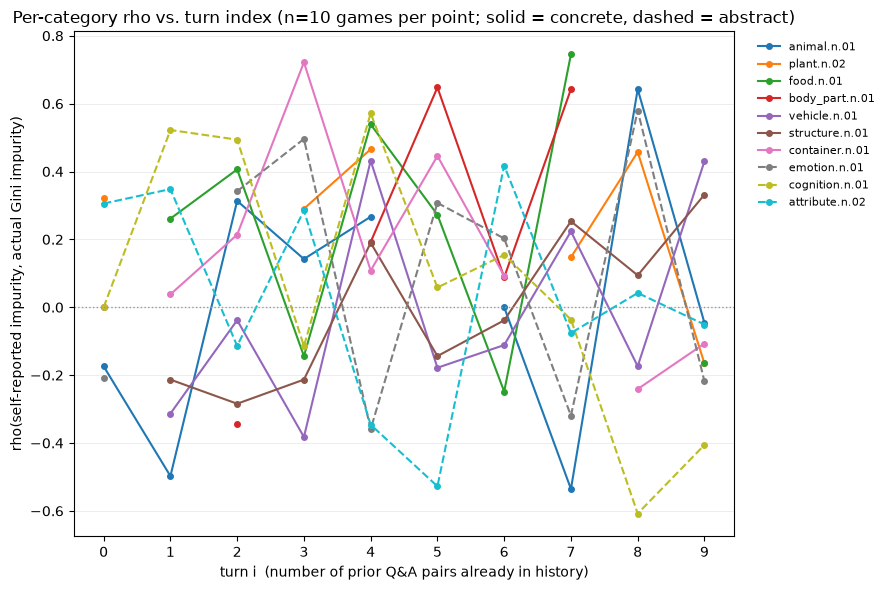

In [12]:
import matplotlib.pyplot as plt

rho_by_turn = (
    turns_df.groupby(["category", "turn"])
    .apply(_rho_of)
    .rename("rho")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.tab10.colors  # 10 fixed, distinct hues — one per category, same order as CATEGORIES
for i, category in enumerate(CATEGORIES):
    series = rho_by_turn[rho_by_turn["category"] == category].sort_values("turn")
    is_abstract = category in ABSTRACT_CATEGORIES
    ax.plot(
        series["turn"], series["rho"],
        color=colors[i], linestyle="--" if is_abstract else "-",
        marker="o", markersize=4, linewidth=1.5, label=category,
    )

ax.axhline(0.0, color="0.6", linewidth=1, linestyle=":")
ax.set_xlabel("turn i  (number of prior Q&A pairs already in history)")
ax.set_ylabel("rho(self-reported impurity, actual Gini impurity)")
ax.set_title("Per-category rho vs. turn index (n=10 games per point; solid = concrete, dashed = abstract)")
ax.set_xticks(range(10))
ax.legend(bbox_to_anchor=(1.02, 1.0), loc="upper left", fontsize=8, frameon=False)
ax.grid(True, axis="y", linewidth=0.5, color="0.9")
fig.tight_layout()
plt.show()

**Interpretation.** 10 categories × 10 games × 10 turns = 1000 trials, each game over its own
independently frequency-sampled, category-restricted 100-word keyword universe (rather than
games sharing one fixed list, drawing from the unrestricted vocabulary, or an earlier
3-secret pilot that hand-picked animal categories and saw several sessions collide into
identical question paths). The gate above is a go/no-go check on whether `impurity` tracks the
real partition split at this scale, not a claim about performance beyond it — it aggregates
across all 10 categories, so the concrete-vs-abstract breakdown just below is the actual check
for whether that aggregate number is hiding a real split rather than reflecting a uniform
effect. The validation-gate cell earlier is the other half of this phase's actual go/no-go: if
the batched partition parse didn't look reliable there, the fix belongs there (switch to
`partition_keywords_per_keyword`), before trusting any Gini-impurity number computed from it
here.

## Log every cell to `trial.json`

`impurity` is specific to this dataset. Logged under `dataset="twenty_questions"` for the
aggregate rho, plus one `dataset="twenty_questions:<category>"` record per category so the
concrete/abstract split survives the round-trip through the shared log too.

In [13]:
from vconf import trial_log as TL

records = [{"dataset": "twenty_questions", "om": "impurity", "gt": "gini_impurity", "rho": rho, "n": len(turns_df)}]
for _, row in category_rho.iterrows():
    records.append({
        "dataset": f"twenty_questions:{row['category']}", "om": "impurity", "gt": "gini_impurity",
        "rho": row["rho"], "n": int(row["n"]),
    })

TL.upsert(records, path=TRIAL_LOG_PATH)
print(f"logged {len(records)} cells to {TRIAL_LOG_PATH}")

logged 11 cells to /home/stud_homes/s7846062/fatass/home/thesis/experiment/code_morph/notebooks_benzon/phase_0_calibration/cache/qwen/trial.json
